# Fun with Seaborn


In [33]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Load all the things!
**sns** comes with some datasets to experiment with. The following code will load each dataset into a Pandas dataframe with the same name as the dataset, printing the name of each dataset as it is loaded. 

Note:
This code uses a metaprogramming trick to create a global variable: the builtin function *globals* returns a live mutable dictionary of all the global variables. It also uses **warnings.catch_warnings()** to suppress a warning that comes from the **Beautiful Soup** module.

In [34]:
import warnings
with warnings.catch_warnings(record=True):
    g = globals()
    for dataset_name in sns.get_dataset_names():
        print(dataset_name)
        g[dataset_name] = sns.load_dataset(dataset_name)


anagrams
anscombe
attention
brain_networks
car_crashes
diamonds
dots
dowjones
exercise
flights
fmri
geyser
glue
healthexp
iris
mpg
penguins
planets
seaice
taxis
tips
titanic


In [35]:
for sex in 'female', 'male':
    print(sex)
    print(titanic[titanic['sex'] == sex]['age'].min())
    print(titanic[titanic['sex'] == sex]['age'].max())
    print(titanic[titanic['sex'] == sex]['age'].median())
    print(titanic[titanic['sex'] == sex]['age'].mean())
    


female
0.75
63.0
27.0
27.915708812260537
male
0.42
80.0
29.0
30.72664459161148


In [36]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


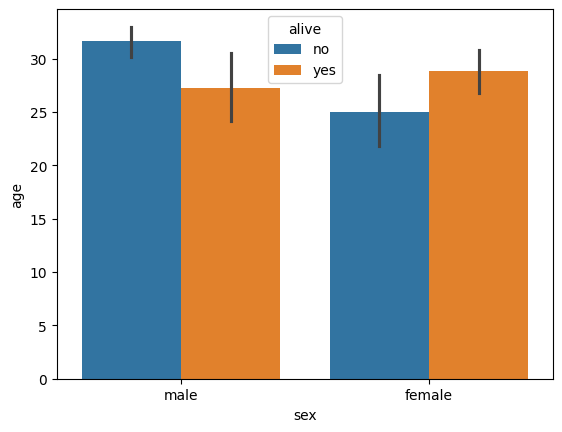

In [37]:
ax = sns.barplot(data=titanic, x='sex', y='age', hue='alive')

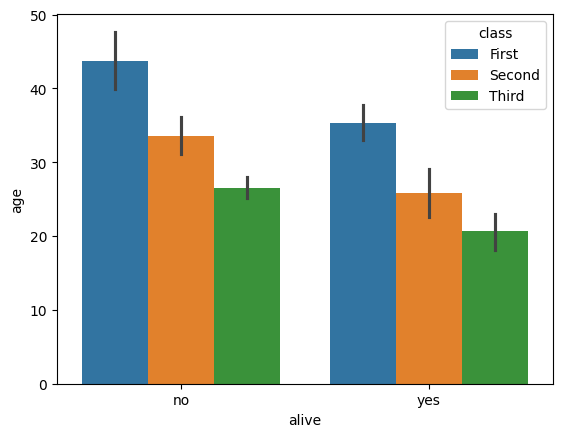

In [38]:
ax = sns.barplot(data=titanic, x='alive', y='age', hue='class')

In [39]:
vc = titanic.value_counts('pclass')
vc

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [40]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [41]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='species'>

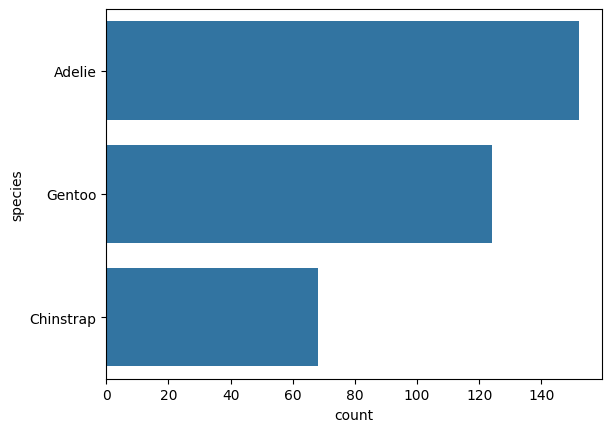

In [42]:
vc = penguins.value_counts('species')
print(vc)
sns.barplot(x=vc, y=vc.index)

In [43]:
vc = titanic.value_counts('class')
vc

class
Third     491
First     216
Second    184
Name: count, dtype: int64

<Axes: xlabel='class', ylabel='count'>

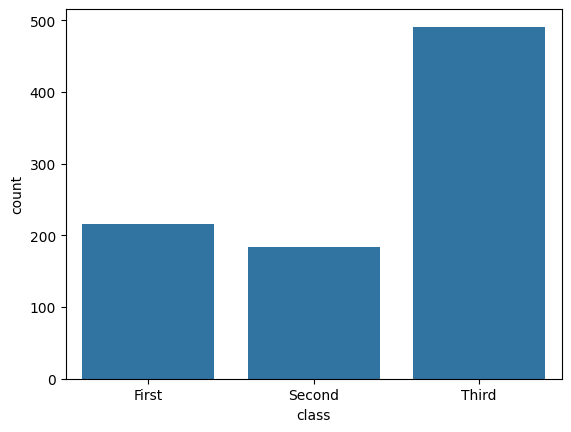

In [44]:
sns.barplot(x=vc.index, y=vc, orient='v')

In [45]:
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


<Axes: xlabel='cylinders', ylabel='count'>

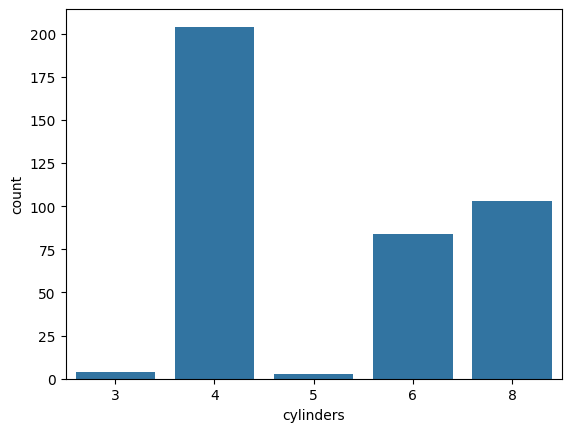

In [46]:
sns.countplot(data=mpg, x='cylinders')

(25.0, 350.0)

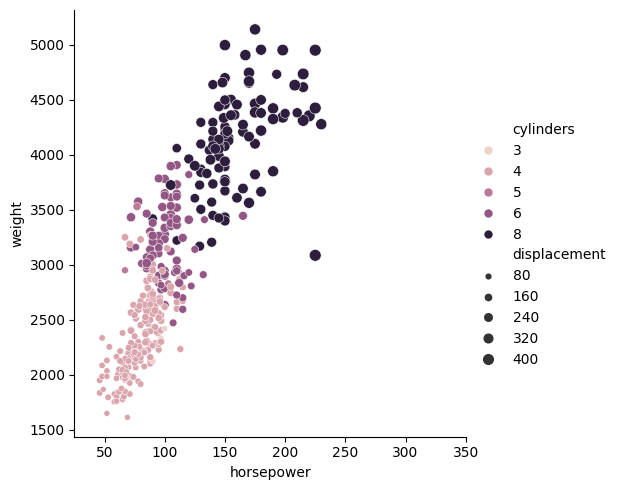

In [47]:
import mpld3
#tooltip = mpld3.plugins.PointLabelTooltip(scatter, labels=labels)
sns.relplot(data=mpg, x='horsepower', y='weight', hue='cylinders', size='displacement')
plt.xlim(25, 350)

<Axes: xlabel='mpg', ylabel='horsepower'>

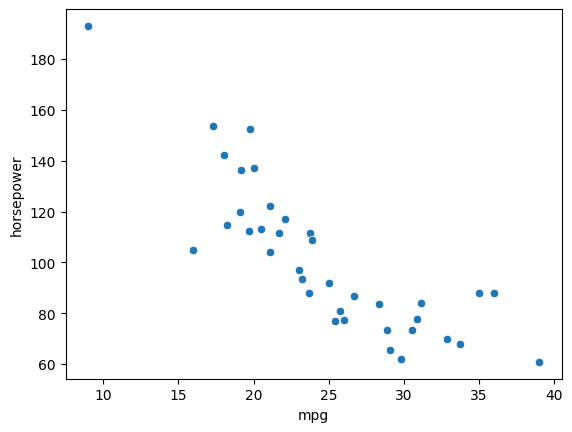

In [48]:
mpg['make'] = mpg['name'].str.split().apply(lambda e: e[0])
data = ((make, data['mpg'].mean(), data['horsepower'].mean()) for make, data in mpg.groupby('make'))  # generator
df = pd.DataFrame(data, columns='make mpg horsepower'.split())
sns.scatterplot(data=df, x='mpg', y='horsepower')

In [49]:
data = ((year, data['mpg'].mean(), data['horsepower'].mean()) for year, data in mpg.groupby('model_year'))  # generator
df = pd.DataFrame(data, columns='year mpg horsepower'.split())
df['year'] += 1900
df

,year,mpg,horsepower
0,1970,17.689655,147.827586
1,1971,21.250000,107.037037
2,1972,18.714286,120.178571
3,1973,17.100000,130.475000
4,1974,22.703704,94.230769
5,1975,20.266667,101.066667
6,1976,21.573529,101.117647
7,1977,23.375000,105.071429
8,1978,24.061111,99.694444
9,1979,25.093103,101.206897


<Axes: xlabel='year', ylabel='mpg'>

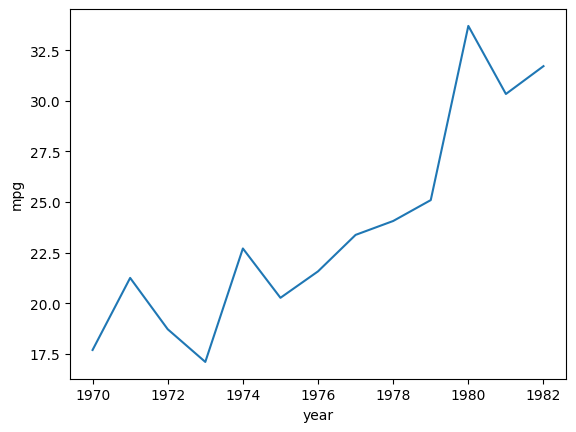

In [50]:
sns.lineplot(data=df, x='year', y='mpg')

<Axes: xlabel='mpg', ylabel='Count'>

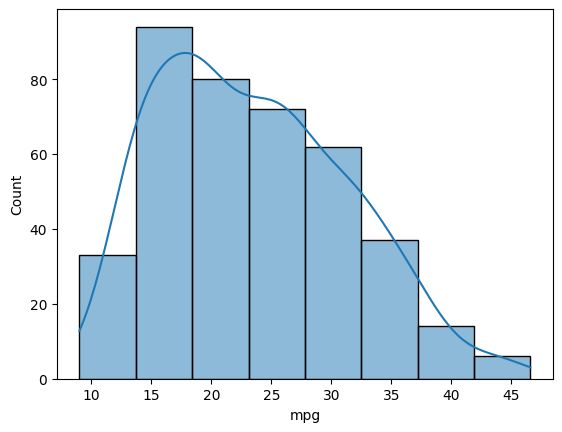

In [64]:
sns.histplot(mpg.mpg, bins=8, kde=True)

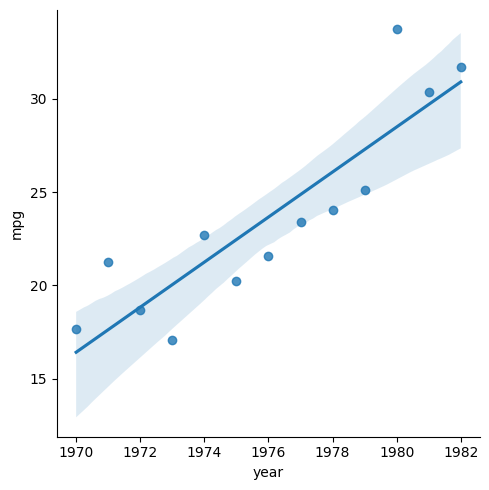

In [52]:
sns.lmplot(data=df, x='year', y='mpg')

In [53]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


<Axes: xlabel='species', ylabel='body_mass_g'>

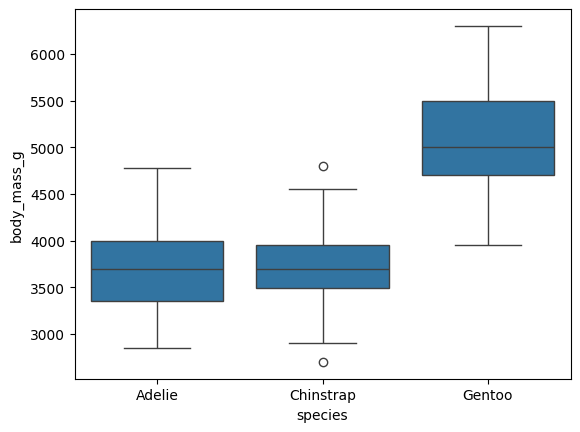

In [54]:
sns.boxplot(data=penguins, y="body_mass_g", x="species")

<Axes: xlabel='species', ylabel='body_mass_g'>

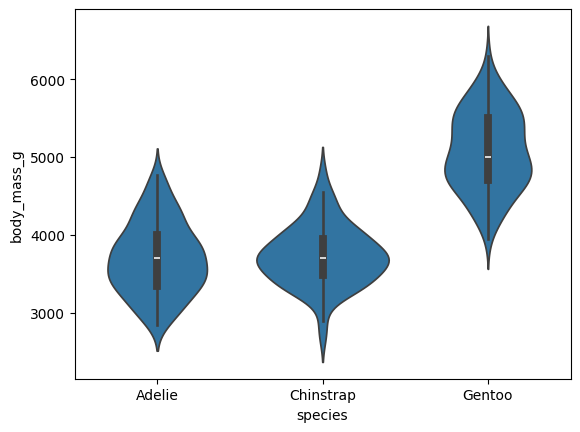

In [55]:
sns.violinplot(data=penguins, y="body_mass_g", x="species")

In [56]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [57]:
titanic.groupby('sex')

In [58]:
titanic.groupby('sex').count().sort_values(by="sex").sort_values(by="deck", ascending=False)

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
sex,,,,,,,,,,,,,,
male,577,577,453,577,577,577,577,577,577,577,106,577,577,577
female,314,314,261,314,314,314,312,314,314,314,97,312,314,314


Exercise: plot the data